In [2]:
from framework import (
    EpsilonGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [3]:
### RUNNING THE MODEL ### 

#Parameters

"""
  a = the constant in front of the term for probability of exploring in every round (epsilon) 
  b = the decay rate beta 
  alpha = learning rate / step size 
  gamma = discount factor for future rewards 

"""

#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)

#run simulation for FPA
simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_FPA = simulation.run()

Convergence detected after 70545 rounds.
Bidder Agent1 had converged to  0.2
Bidder Agent2 had converged to  0.2


In [4]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)

#run simulation for SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_SPA = simulation.run()

Convergence detected after 253734 rounds.
Bidder Agent1 had converged to  0.9500000000000001
Bidder Agent2 had converged to  0.9500000000000001


Giving just one example run we see evidence of collusion in the First Price Auction. Whereas the Second Price Auction converges to the NE. Moreover, the FPA takes 80,000 rounds to converge whereas the SPA takes approx. 3x as long to converge in 235,000 rounds.

##### Evolution of q-value for FPA:

In [5]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

Evolution of the q-value associated to the bid the FPA converged to (0.15).

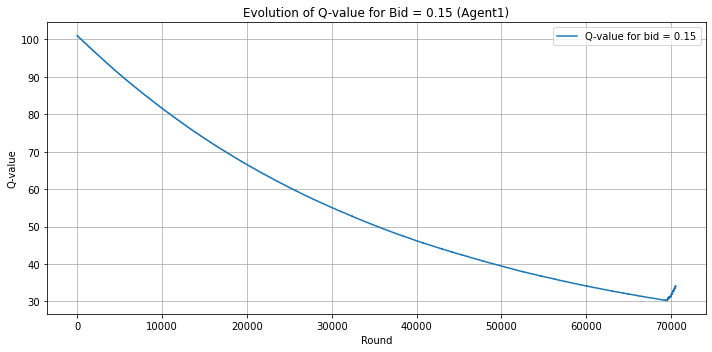

In [15]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 3

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.15")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.15 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now the evolution of the q-value associated to another bid.

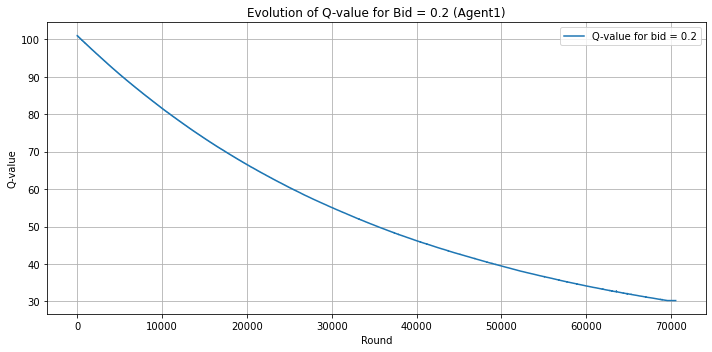

In [16]:
bid_index = 4

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.2")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.2 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now let's look at just the final 5000 rounds to see the evolution in more detail.

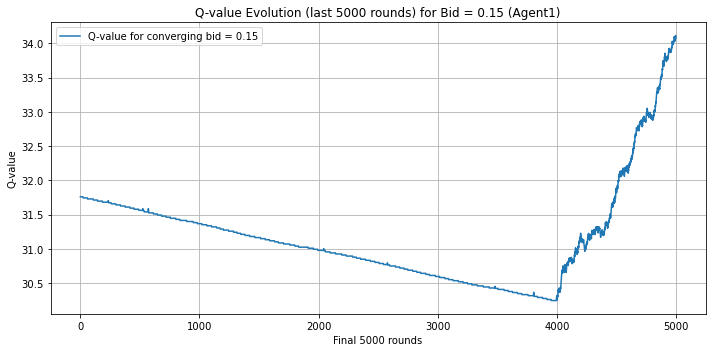

In [17]:
bid_index = 3
bidder_name = "Agent1"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for converging bid = {0.15}")
plt.xlabel("Final 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

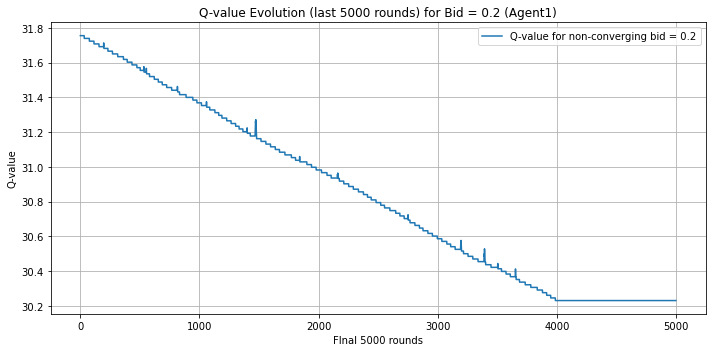

In [18]:
bid_index = 4
bidder_name = "Agent1"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for non-converging bid = {0.2}")
plt.xlabel("FInal 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.2} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

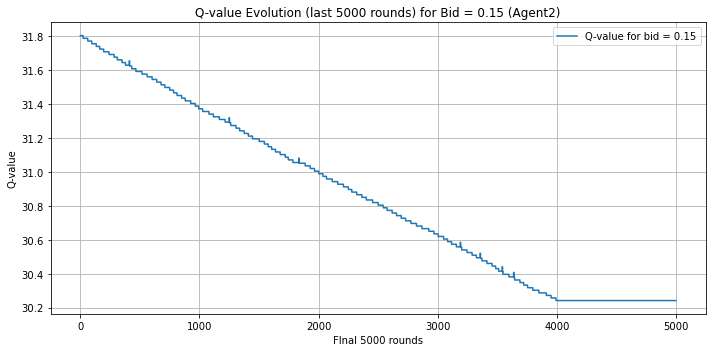

In [10]:
bid_index = 2
bidder_name = "Agent2"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for bid = {0.15}")
plt.xlabel("FInal 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Q-value evolution for SPA:

Had winning bid 0.95 (has index 18).

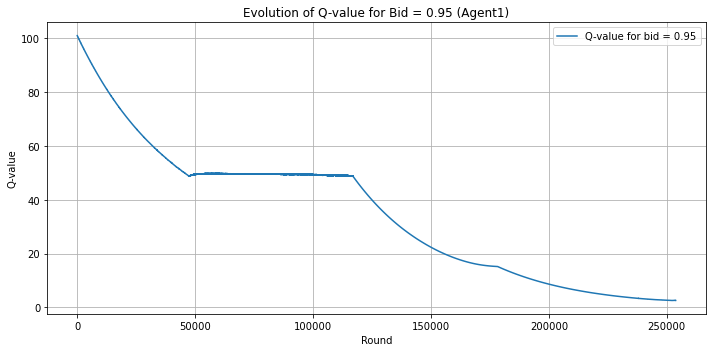

In [19]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 18

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.95")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.95 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

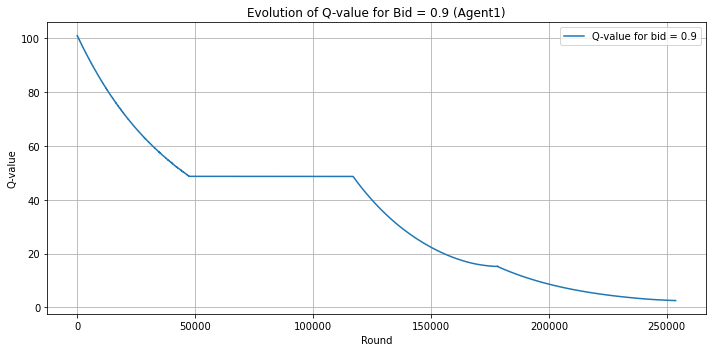

In [12]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 17

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.9")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.9 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

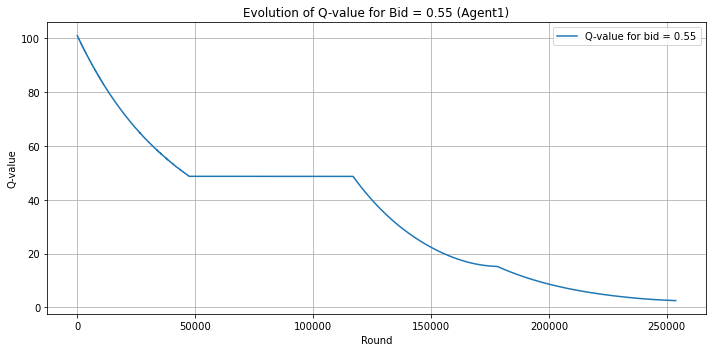

In [13]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 10

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.55")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.55 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### The evolution of the winning bid:

FPA

In [23]:
import numpy as np

def moving_average(data, window_size):
    return [np.mean(data[i:i+window_size]) for i in range(0, len(data) - window_size + 1)]

# Extract raw winning bids
winning_bids_fpa = [entry[2] for entry in history_FPA]
winning_bids_spa = [entry[2] for entry in history_SPA]

# Compute moving averages with window of 10
ma_fpa = moving_average(winning_bids_fpa, window_size=100)
ma_spa = moving_average(winning_bids_spa, window_size=100)

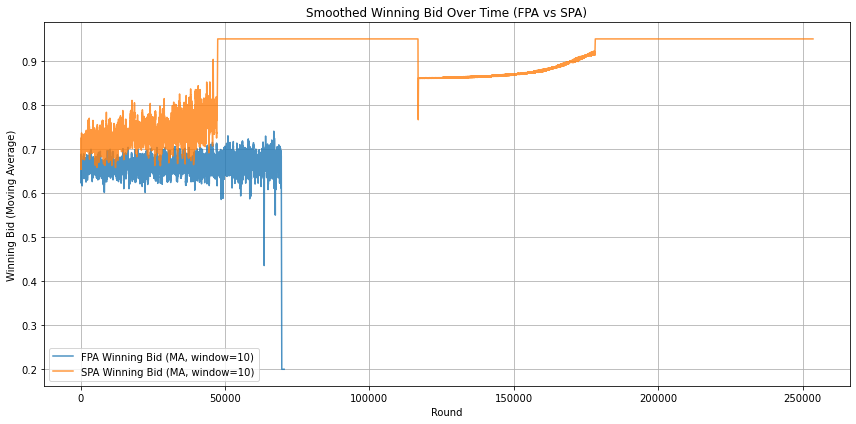

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(ma_fpa, label="FPA Winning Bid (MA, window=10)", alpha=0.8)
plt.plot(ma_spa, label="SPA Winning Bid (MA, window=10)", alpha=0.8)
plt.xlabel("Round")
plt.ylabel("Winning Bid (Moving Average)")
plt.title("Smoothed Winning Bid Over Time (FPA vs SPA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### General results from multiple simulations:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results = pd.read_csv("FPA_auction_summary_results.csv")

In [30]:
results.head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,0,77931,0.35,29.240635,0.35,30.062590
1,1,91825,0.40,26.429556,0.40,26.300220
2,2,78883,0.10,33.982775,0.10,34.712292
3,3,87492,0.25,29.588319,0.25,30.389061
4,4,86197,0.35,28.107094,0.35,28.263019


In [6]:
print("The mean bid converged to for agent 1 was ", results["converged_bid_Agent1"].mean())
print("The mean bid converged to for agent 2 was ", results["converged_bid_Agent2"].mean())

The mean bid converged to for agent 1 was  0.22750000000000006
The mean bid converged to for agent 2 was  0.22750000000000006


Exactly the same because they always converge to the same bid.

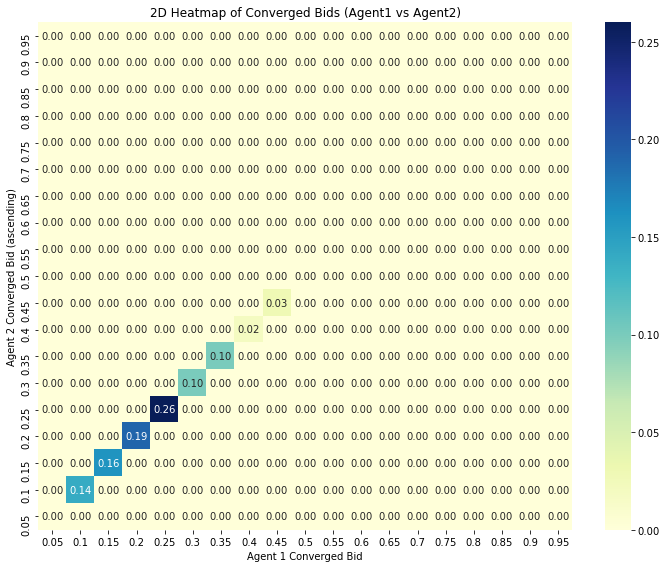

In [ ]:
import seaborn as sns

bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

for b1, b2 in zip(results["converged_bid_Agent1"], results["converged_bid_Agent2"]):
    heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=heatmap_matrix.index)
plt.title("2D Heatmap of Converged Bids (Agent1 vs Agent2)")
plt.xlabel("Agent 1 Converged Bid")
plt.ylabel("Agent 2 Converged Bid (ascending)")
plt.tight_layout()
plt.show()

The fact they always converge to the same bid can be seen as only values along the diagonal have any results.

In [33]:
mean_rounds = results["rounds_to_convergence"].mean()
print("Mean rounds to convergence:", mean_rounds)

Mean rounds to convergence: 77034.11


In [36]:
agent1_mean_q = results["converged_q_Agent1"].mean()
agent2_mean_q = results["converged_q_Agent2"].mean()

print("The mean q-value Agent1 converged to was", agent1_mean_q)
print("The mean q-value Agent2 converged to was", agent2_mean_q)

The mean q-value Agent1 converged to was 32.310272704193395
The mean q-value Agent2 converged to was 32.30355619999626


In [39]:
agent1_variance_q = results["converged_q_Agent1"].var()
agent2_variance_q = results["converged_q_Agent2"].var()

print("The variance of converged q-values for Agent1 was", agent1_variance_q)
print("The variance of converged q-values for Agent2 was", agent2_variance_q)

The variance of converged q-values for Agent1 was 6.786746749101875
The variance of converged q-values for Agent2 was 7.087259024066352


The q-value that the algorithms converge to are clearly drawn from the same distribution.

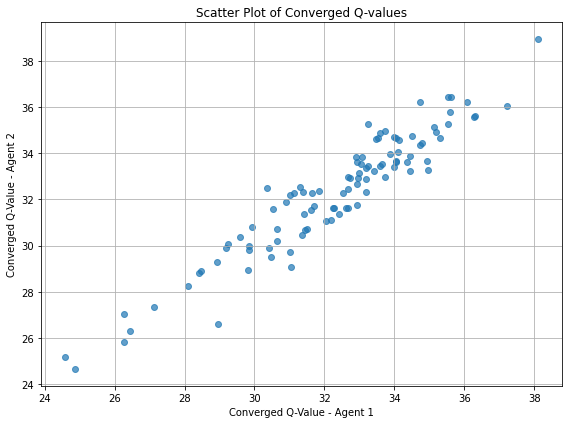

In [37]:
# Scatter plot: Agent 1 Q vs Agent 2 Q
plt.figure(figsize=(8, 6))
plt.scatter(results["converged_q_Agent1"], results["converged_q_Agent2"], alpha=0.7)
plt.title("Scatter Plot of Converged Q-values")
plt.xlabel("Converged Q-Value - Agent 1")
plt.ylabel("Converged Q-Value - Agent 2")
plt.grid(True)
plt.tight_layout()
plt.show()

Relationship is linear as expected.

##### Analysis for SPA:

In [40]:
results_SPA = pd.read_csv("SPA_auction_summary_results.csv")

In [41]:
results_SPA.head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,0,243923,0.95,17.359193,0.95,2.509803
1,1,257225,0.95,16.870756,0.95,2.527931
2,2,238288,0.95,2.555876,0.95,16.307231
3,3,240071,0.95,2.544152,0.95,17.009763
4,4,241059,0.95,2.573469,0.95,21.570669


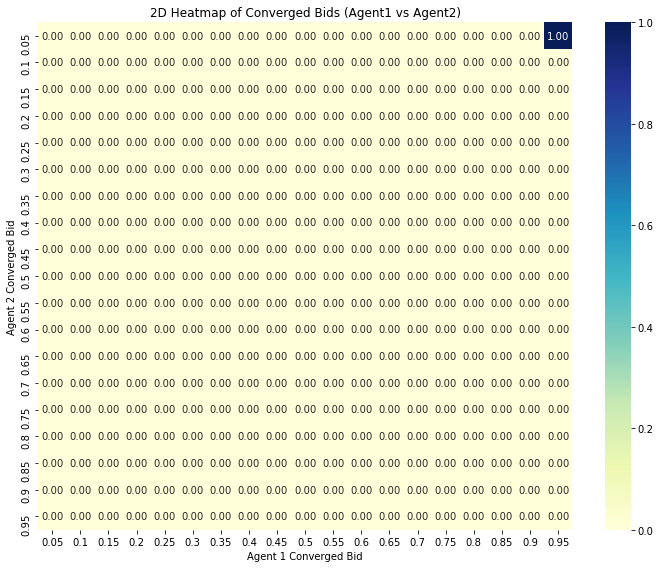

In [47]:
bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

for b1, b2 in zip(results_SPA["converged_bid_Agent1"], results_SPA["converged_bid_Agent2"]):
    heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=bid_options)
plt.title("2D Heatmap of Converged Bids (Agent1 vs Agent2)")
plt.xlabel("Agent 1 Converged Bid")
plt.ylabel("Agent 2 Converged Bid")
plt.tight_layout()
plt.show()

In [49]:
mean_rounds = results_SPA["rounds_to_convergence"].mean()
print("Mean rounds to convergence:", mean_rounds)

Mean rounds to convergence: 257089.91


In [51]:
agent1_mean_q = results_SPA["converged_q_Agent1"].mean()
agent2_mean_q = results_SPA["converged_q_Agent2"].mean()

print("The mean q-value Agent1 converged to was", agent1_mean_q)
print("The mean q-value Agent2 converged to was", agent2_mean_q)

The mean q-value Agent1 converged to was 9.391981439645361
The mean q-value Agent2 converged to was 10.268310736536225


In [53]:
agent1_variance_q = results_SPA["converged_q_Agent1"].var()
agent2_variance_q = results_SPA["converged_q_Agent2"].var()

print("The variance of converged q-values for Agent1 was", agent1_variance_q)
print("The variance of converged q-values for Agent2 was", agent2_variance_q)

The variance of converged q-values for Agent1 was 58.355088605548666
The variance of converged q-values for Agent2 was 57.79937054481531


Much greater variance in the q-values that the SPA converges to.

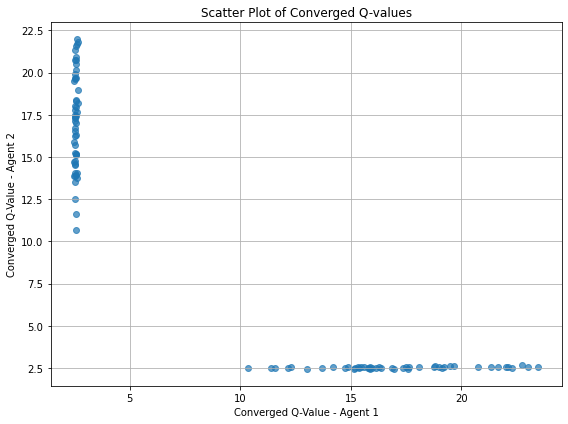

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(results_SPA["converged_q_Agent1"], results_SPA["converged_q_Agent2"], alpha=0.7)
plt.title("Scatter Plot of Converged Q-values")
plt.xlabel("Converged Q-Value - Agent 1")
plt.ylabel("Converged Q-Value - Agent 2")
plt.grid(True)
plt.tight_layout()
plt.show()

Completely different relationship of the convergence of the q-values. One always goes to around 2.5 and the other a greater value with more variability.

What's causing this behaviour?

#### Asymmetry:

First a look at assymetry in the values. Agent1 will keep value 1 and Agent2 will have a lower value of 0.7.

In [7]:
import pandas as pd

results = pd.read_csv("FPA_asymmetry1_results.csv")

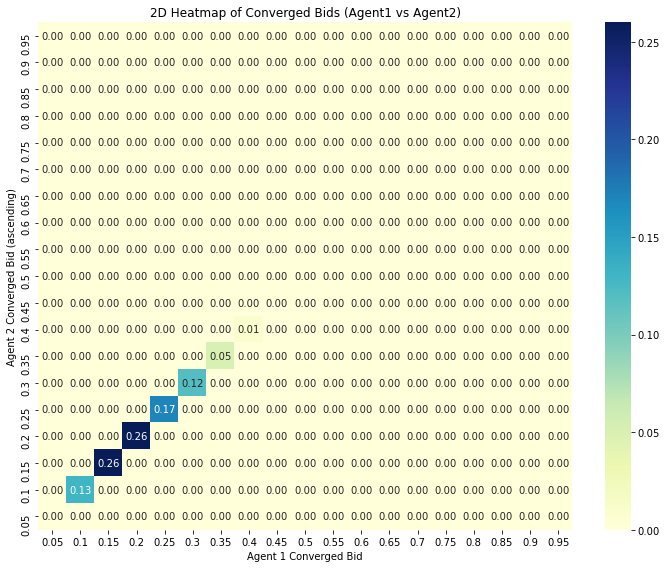

In [8]:
import seaborn as sns

bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

for b1, b2 in zip(results["converged_bid_Agent1"], results["converged_bid_Agent2"]):
    heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=heatmap_matrix.index)
plt.title("2D Heatmap of Converged Bids (Agent1 vs Agent2)")
plt.xlabel("Agent 1 Converged Bid")
plt.ylabel("Agent 2 Converged Bid (ascending)")
plt.tight_layout()
plt.show()

In [11]:
results.head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,0,83396,0.25,32.349461,0.25,18.268458
1,1,62725,0.10,39.744591,0.10,25.459837
2,2,80984,0.10,35.549600,0.10,21.685604
3,3,73289,0.30,33.623129,0.30,18.787398
4,4,80594,0.25,33.697321,0.25,18.116521


In [13]:
print("The mean bid of Agent1 was ", results["converged_bid_Agent1"].mean())
print("The mean bid of Agent2 was ", results["converged_bid_Agent2"].mean())

The mean bid of Agent1 was  0.204
The mean bid of Agent2 was  0.204


In [9]:
mean_rounds = results["rounds_to_convergence"].mean()
print("Mean rounds to convergence:", mean_rounds)

Mean rounds to convergence: 79310.54


In [10]:
agent1_mean_q = results["converged_q_Agent1"].mean()
agent2_mean_q = results["converged_q_Agent2"].mean()

print("The mean q-value Agent1 converged to was", agent1_mean_q)
print("The mean q-value Agent2 converged to was", agent2_mean_q)

The mean q-value Agent1 converged to was 34.83439209151766
The mean q-value Agent2 converged to was 19.493284075905997


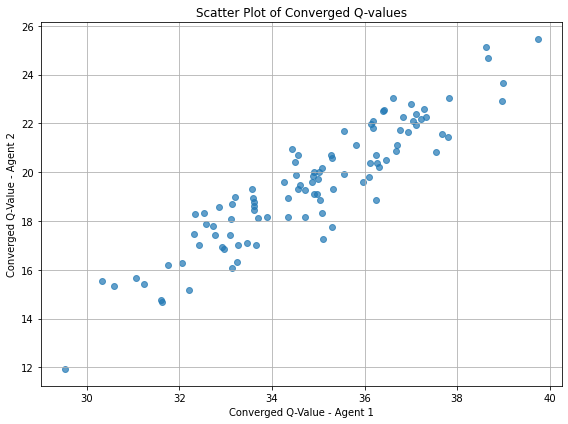

In [14]:
# Scatter plot: Agent 1 Q vs Agent 2 Q
plt.figure(figsize=(8, 6))
plt.scatter(results["converged_q_Agent1"], results["converged_q_Agent2"], alpha=0.7)
plt.title("Scatter Plot of Converged Q-values")
plt.xlabel("Converged Q-Value - Agent 1")
plt.ylabel("Converged Q-Value - Agent 2")
plt.grid(True)
plt.tight_layout()
plt.show()